### Importar Librerias

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
from collections import Counter
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
nltk.download('wordnet')
nltk.download('punkt')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [46]:
from transformers import pipeline
from sklearn.metrics import f1_score

### Business Understanding

In [47]:
df = pd.read_csv('Reviews.csv')

In [48]:
df.shape

(568454, 10)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [50]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [51]:
df['Score'].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [52]:
df['Score'].unique()

array([5, 1, 4, 2, 3])

In [53]:
def get_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['Score'].apply(get_sentiment)
print(df['sentiment'].value_counts())

sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64


In [54]:
print(df['sentiment'].value_counts(normalize=True))

sentiment
positive    0.780674
negative    0.144316
neutral     0.075010
Name: proportion, dtype: float64


In [55]:
# Elimina los neutros
df_binary = df[df['sentiment'] != 'neutral'].copy()

# Convierte a binario numérico
df_binary['label'] = (df_binary['sentiment'] == 'positive').astype(int)

print(df_binary['label'].value_counts())
print(f"Shape: {df_binary.shape}")

label
1    443777
0     82037
Name: count, dtype: int64
Shape: (525814, 12)


In [56]:
print(df_binary['label'].value_counts(normalize=True))

label
1    0.843981
0    0.156019
Name: proportion, dtype: float64


In [57]:
# Toma 20,000 muestras de cada clase para balancear
df_pos = df_binary[df_binary['label'] == 1].sample(20000, random_state=42)
df_neg = df_binary[df_binary['label'] == 0].sample(20000, random_state=42)

# Unir ambas clases
df_sample = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42)

print(df_sample['label'].value_counts())
print(f"Shape: {df_sample.shape}")

label
0    20000
1    20000
Name: count, dtype: int64
Shape: (40000, 12)


In [58]:
print(df_sample['label'].value_counts(normalize=True))

label
0    0.5
1    0.5
Name: proportion, dtype: float64


### Analisis Exploratorio de Datos (EDA)

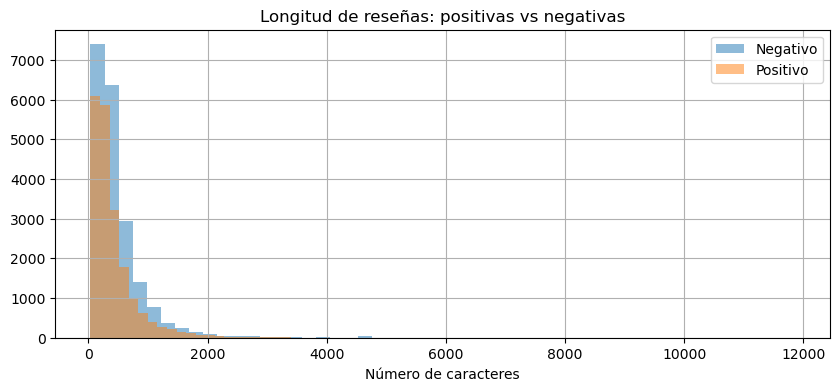

         count       mean         std   min    25%    50%    75%      max
label                                                                    
0      20000.0  488.37160  506.588256  33.0  206.0  348.0  587.0  11861.0
1      20000.0  419.14645  421.235132  33.0  173.0  290.5  501.0   8063.0


In [59]:
# Longitud de las reseñas
df_sample['text_length'] = df_sample['Text'].apply(len)

# Distribución de longitud por sentimiento
df_sample.groupby('label')['text_length'].hist(
    alpha=0.5, bins=50, figsize=(10,4)
)
plt.title("Longitud de reseñas: positivas vs negativas")
plt.xlabel("Número de caracteres")
plt.legend(['Negativo', 'Positivo'])
plt.show()

print(df_sample.groupby('label')['text_length'].describe())

In [60]:
df_sample['Text'].head()

38707     The coconut milk was NOT Light. I bought it be...
107194    Our family absolutely loves these graham style...
381566    I ordered this product to give myself some var...
298090    Smart Fries are a great, healthy snack that my...
91586     I liked the product, but several units were ba...
Name: Text, dtype: object

In [61]:
# palabras dominan cada sentimiento

stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    # Unir todo el texto
    all_words = ' '.join(texts).lower()
    
    # limpiar texto (n'umeros, signos, simbolos)
    all_words = re.sub(r'[^a-z\s]', '', all_words)
    
    # tokenizar
    words = all_words.split()

    # filtrar palabras
    words = [w for w in words if w not in stop_words and len(w) > 2]

    # contar palabras y obtener top N
    return Counter(words).most_common(n)

print("TOP palabras POSITIVAS:")
print(get_top_words(df_sample[df_sample['label']==1]['Text']))

print("\nTOP palabras NEGATIVAS:")
print(get_top_words(df_sample[df_sample['label']==0]['Text']))

TOP palabras POSITIVAS:
[('like', 8143), ('good', 7057), ('great', 6639), ('one', 5709), ('coffee', 5670), ('taste', 5383), ('love', 5037), ('flavor', 4837), ('tea', 4763), ('product', 4587), ('food', 4289), ('would', 3681), ('get', 3657), ('really', 3296), ('use', 3120), ('also', 3113), ('dont', 3085), ('little', 3078), ('much', 3063), ('best', 3030)]

TOP palabras NEGATIVAS:
[('like', 10806), ('product', 7768), ('taste', 7680), ('one', 6824), ('would', 6493), ('food', 5435), ('coffee', 5420), ('good', 5187), ('flavor', 4888), ('dont', 4277), ('even', 4162), ('tea', 4027), ('get', 3943), ('buy', 3629), ('really', 3512), ('much', 3380), ('amazon', 3284), ('tried', 3000), ('first', 2845), ('dog', 2831)]


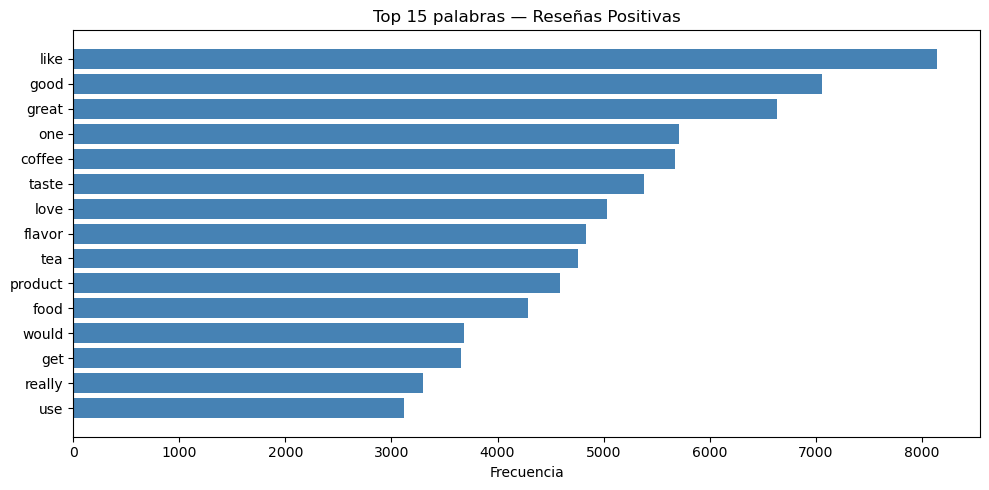

In [62]:
# Top palabras positivas
top_pos = get_top_words(df_sample[df_sample['label']==1]['Text'], n=15)
words_pos, counts_pos = zip(*top_pos)

plt.figure(figsize=(10,5))
plt.barh(words_pos, counts_pos, color='steelblue')
plt.title("Top 15 palabras — Reseñas Positivas")
plt.xlabel("Frecuencia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

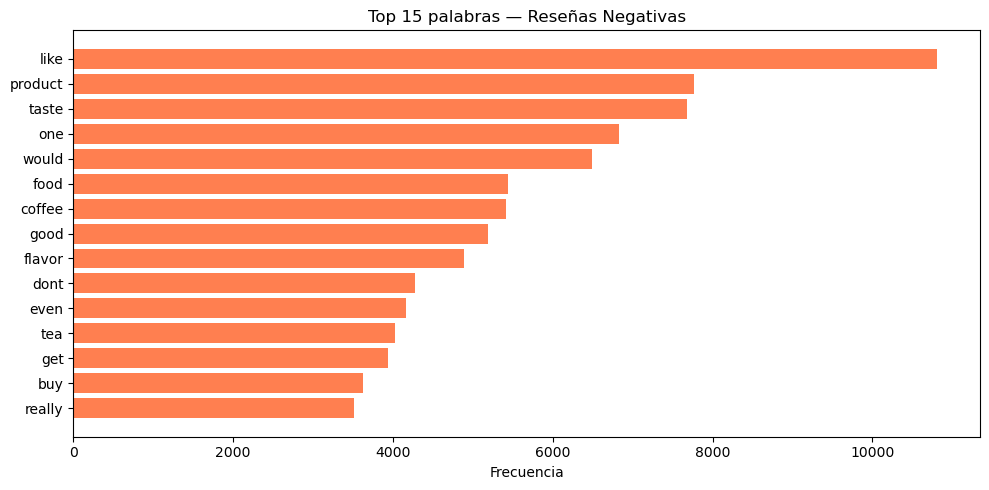

In [63]:
# Top palabras negativas
top_neg = get_top_words(df_sample[df_sample['label']==0]['Text'], n=15)
words_neg, counts_neg = zip(*top_neg)

plt.figure(figsize=(10,5))
plt.barh(words_neg, counts_neg, color='coral')
plt.title("Top 15 palabras — Reseñas Negativas")
plt.xlabel("Frecuencia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Preprocesamiento de texto

In [64]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Eliminar puntuación y números
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenizar
    tokens = text.split()
    # Eliminar stopwords y palabras cortas
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    # Lemmatizar
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

In [65]:
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

# Verificar el resultado
print("\nTexto original:")
print(df_sample['Text'].iloc[0])
print("\nTexto limpio:")
print(df_sample['clean_text'].iloc[0])


Texto original:
The coconut milk was NOT Light. I bought it because it was a case of light coconut milk but it is not.

Texto limpio:
coconut milk light bought case light coconut milk


In [66]:
# Excluir "not", "never", "no" de las stopwords
stop_words = set(stopwords.words('english'))
stop_words -= {'not', 'never', 'no', 'nor'}

# Vuelvo a limpiar el dataset
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

In [67]:
# Verificar el resultado del mismo ejemplo
print("\nTexto original:")
print(df_sample['Text'].iloc[0])
print("\nTexto limpio:")
print(df_sample['clean_text'].iloc[0])


Texto original:
The coconut milk was NOT Light. I bought it because it was a case of light coconut milk but it is not.

Texto limpio:
coconut milk not light bought case light coconut milk not


### Vectorización con TF-IDF

In [68]:
# Split primero — importante hacerlo ANTES de vectorizar
X = df_sample['clean_text']
y = df_sample['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vectorizar
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape train: {X_train_tfidf.shape}")
print(f"Shape test:  {X_test_tfidf.shape}")

Shape train: (32000, 10000)
Shape test:  (8000, 10000)


### Entrenamiento del modelo

In [69]:
# Fit
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

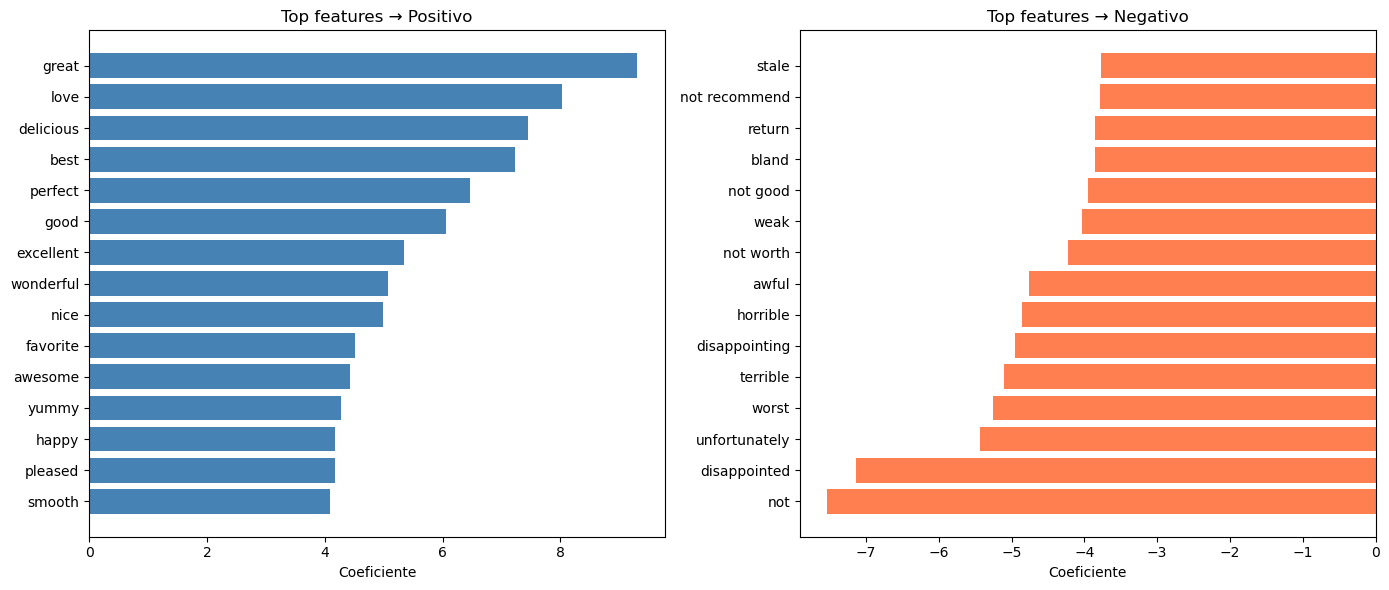

In [70]:
# Extrae los coeficientes del modelo
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]

# Top 15 palabras más positivas y negativas
top_positive_idx = np.argsort(coefs)[-15:]
top_negative_idx = np.argsort(coefs)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# Positivas
ax1.barh(feature_names[top_positive_idx], 
         coefs[top_positive_idx], color='steelblue')
ax1.set_title("Top features → Positivo")
ax1.set_xlabel("Coeficiente")

# Negativas
ax2.barh(feature_names[top_negative_idx], 
         coefs[top_negative_idx], color='coral')
ax2.set_title("Top features → Negativo")
ax2.set_xlabel("Coeficiente")

plt.tight_layout()
plt.show()

In [71]:
# Evaluar
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.89      0.90      0.90      4000
    Positive       0.90      0.89      0.90      4000

    accuracy                           0.90      8000
   macro avg       0.90      0.90      0.90      8000
weighted avg       0.90      0.90      0.90      8000



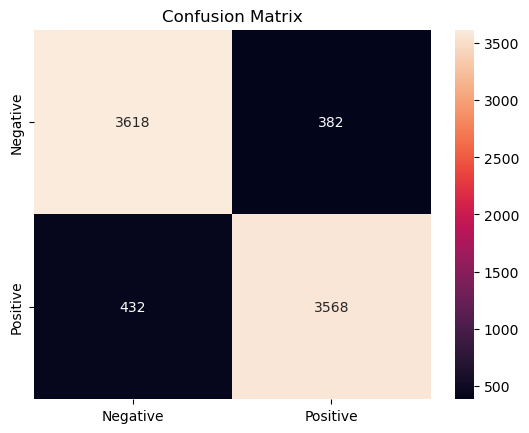

In [72]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("Confusion Matrix")
plt.show()

### BERT

In [73]:
# Carga modelo preentrenado de HuggingFace
classifier = pipeline("sentiment-analysis")

# Prueba con ejemplos reales de tu dataset
ejemplos = [
    "This product is absolutely amazing, I love it!",
    "Terrible quality, broke after one day, never buying again",
    "The coconut milk was NOT light, very disappointed"
]

for texto in ejemplos:
    resultado = classifier(texto)
    print(f"Texto: {texto[:50]}...")
    print(f"Resultado: {resultado}\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Texto: This product is absolutely amazing, I love it!...
Resultado: [{'label': 'POSITIVE', 'score': 0.9998841285705566}]

Texto: Terrible quality, broke after one day, never buyin...
Resultado: [{'label': 'NEGATIVE', 'score': 0.9975677132606506}]

Texto: The coconut milk was NOT light, very disappointed...
Resultado: [{'label': 'NEGATIVE', 'score': 0.9996931552886963}]



### Comparación entre ambos modelos (TF_IDF vs BERT)  

In [74]:
# Evalúa BERT en una muestra pequeña (es lento)
muestra_test = df_sample.sample(100, random_state=42)

bert_preds = []
for texto in muestra_test['Text']:
    resultado = classifier(texto[:512])  # BERT tiene límite de 512 tokens
    label = 1 if resultado[0]['label'] == 'POSITIVE' else 0
    bert_preds.append(label)


f1_bert = f1_score(muestra_test['label'], bert_preds)
print(f"F1 BERT (100 muestras):      {f1_bert:.4f}")
print(f"F1 TF-IDF (dataset completo): 0.9000")

F1 BERT (100 muestras):      0.8400
F1 TF-IDF (dataset completo): 0.9000
